## Apresentação 

Notebook destinado ao estudo da representação dos textos em NLP. A representação textual é a parte que busca efetivamente transformar o que está em linguagem natural para uma representação numérica, que permite a "interpretação" pelos computadores. Nesse sentido, irá ser passado as principais formas de representação existentes, realizando um breve comentário sobre cada qual em sua respectiva parte. 


### Library

In [39]:
import nltk

nltk.download("punkt")

from string import punctuation
from nltk.tokenize import word_tokenize 

from langchain_huggingface.embeddings import HuggingFaceEmbeddings

from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Bruno\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


#### One-hot encoding

O one-hot encoding é a forma mais básica de codificação realizada para traduzir o que está em linguagem natural para uma representação numérica, podendo ser compreendido também como um mapeamento da presença de um termo numa sentença. Por exemplo, se existissem as duas frases "eu gosto de retrowave" e "de blackmetal eu não gosto", a representação dessas poderia se dar da seguinte forma : 

- 1° frase : 0 1 0 
- 2° frase : 0 0 1 0

Na primeira frase é monitorado a ocorrência do termo `gosto`, sendo mapeado como o segundo valor, enquanto que na segunda frase há o maepeamento do `não`, que é verificado na terceira posição. Em uma notação vetorial, tais frases ficariam da seguinte forma: 

- 1° frase: [0, 1, 0]
- 2° frase: [0, 0, 1, 0]

Como pode-se notar, tal abordagem tende a formar vetores esparços - vetores com elevada presença de 0 -, o que pode representar um empecilho para o treinamento de modelos de machine learning. Por outro lado, outro aspecto negativo do one-hot encoding é a sua falta de apreensão semântica. Como ela se refere a uma forma de mapear a existência de cada termo presente numa sentença, por meio de marcações binárias, não é capaz de relacionar os termos presentes segundo o ponto de vista semântico, uma vez que cada termo em sua perspectiva é assumido de forma independente e sem associação alguma entre si. 


**Obs:** Eu removi a preposição dessa frase, uma vez que pode ser compreendida como uma stopword não apresentando carga semântica para as frases. 


In [9]:
T1 = 'dog bites man'
T2 = 'man bites dog'
T3 = 'dog eats meat'
T4 = 'man eats food'

data = [T1.split(), T2.split(), T3.split(), T4.split()]
values = data[0]+data[1]+data[2]+data[3]

print("Data: ", values)

onehot_encoder = OneHotEncoder()
onehot_encoder = onehot_encoder.fit_transform(data).toarray()
print("\n\nOnehot encoded matrix:\n\n", onehot_encoder)

Data:  ['dog', 'bites', 'man', 'man', 'bites', 'dog', 'dog', 'eats', 'meat', 'man', 'eats', 'food']


Onehot encoded matrix:

 [[1. 0. 1. 0. 0. 0. 1. 0.]
 [0. 1. 1. 0. 1. 0. 0. 0.]
 [1. 0. 0. 1. 0. 0. 0. 1.]
 [0. 1. 0. 1. 0. 1. 0. 0.]]


### Bag of words

Bag of words (mochila de palavras numa tradução livre) se refere ao vocabulário utilizado para mapear determinadas palavras segundo uma representação numérica. Dessa forma as palavras podem ser compreendidas segundo por meio de números, como por exemplo. Suponha a frase : darkwave é legal, de modo que os termos (não stopwords) são representados da seguinte forma, respectivamente 5 e 8. A frase então informada poderia ser entendida como: [5, 8]. 

Com base nisso, constitui-se com uma alternativa ao one-hot encoding, tendo em vista que as sentenças agora processadas tendem a não formar vetores esparços, concebendo em cada slot, por assim dizer, a representação numérica de alguma palavra, signo ou caractere qualquer. 

In [13]:
documents = ["Dog bites man.", "Man bites dog.", "Dog eats meat.", "Man eats food."] 
processed_docs = [doc.lower().replace(".","") for doc in documents]
processed_docs

['dog bites man', 'man bites dog', 'dog eats meat', 'man eats food']

In [16]:
count_vect = CountVectorizer()
bow = count_vect.fit_transform(processed_docs)

print(f"Corpus original: {processed_docs}")
print(f"\nVocabulário: {count_vect.vocabulary_}")


Corpus original: ['dog bites man', 'man bites dog', 'dog eats meat', 'man eats food']

Vocabulário: {'dog': 1, 'bites': 0, 'man': 4, 'eats': 2, 'meat': 5, 'food': 3}


In [19]:
# Verificando a 1° frase com bag of words:

print(bow[0])

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3 stored elements and shape (1, 6)>
  Coords	Values
  (0, 1)	1
  (0, 0)	1
  (0, 4)	1


In [20]:
print(bow[0].toarray())

[[1 1 0 0 1 0]]


O mapeamento dos termos presentes por meio da bag of words também podem se direcionar a mais de um N-gramn, como pode ser visto na célula a seguir. Mas, antes, para fins de contextualização, pode-se pensar que um N-gramns se refere a porções de um texto, de modo que para a frase eu gosto de sinth wave, ficaria : 


- 1-Gramn : ["Eu" "gosto" "de" "sinth" "wave"]
- 2-Gramn : ["Eu gosto" "de sinth" "wave"]

.

.

.

(e assim por diante). 

Cada palavra entre aspas representa um gramn.

In [21]:
count_vect_with_n_gramns = CountVectorizer(ngram_range=(1,2))

bow_n_gramns = count_vect_with_n_gramns.fit_transform(processed_docs)

print("Vocabulário: ", count_vect_with_n_gramns.vocabulary_)

Vocabulário:  {'dog': 3, 'bites': 0, 'man': 10, 'dog bites': 4, 'bites man': 2, 'man bites': 11, 'bites dog': 1, 'eats': 6, 'meat': 13, 'dog eats': 5, 'eats meat': 8, 'food': 9, 'man eats': 12, 'eats food': 7}


### TF-IDF

TF-IDF é uma abordagem que busca representar os termos presentes numa sentença segunda uma relação dupla de frequência (TF) e de frequência inversa (IDF) da seguinte forma : a primeira considera a frequência que um termo apresenta num documento - que pode ser compreendido como o corpo de um texto -, mas raramente noutros, enquanto o segundo considera a frequência de um termo em relação a todos os outros documentos. 

A principal ideia do TF-IDF é atribuir maior peso aos termos que são frequentes em um documento particular, ao passo que efetua uma penalização nos termos que aparece em todos os documentos de forma frequente, uma vez que normalmente estarão associadas a termos tais como stopwords, que não carregam peso semântico para o entendimento da mensagem. 

Da mesma forma, o TF-IDF pode ser compreendido da seguinte forma: 

- TF

$$
TF(t, d) = \frac{\text{Número de vezes que } t \text{ aparece em } d}{\text{Total de termos em } d}
$$

- IDF

$$
IDF(t, D) = \log \left(\frac{N}{1 + DF(t)}\right)
$$

- TF-IDF

$$
TF-IDF(t, d, D) = TF(t, d) \times IDF(t, D)
$$

Uma de suas principais forças é conseguir realizar uma representação numérica para palavras presentes no texto, ao mesmo tempo em que auxilia a remover palavras não relevantes. Contudo, os seus principais entraves se associa ao fato de não conseguir captar o contexto da mensagem e ignorar aspecto semântico do termo, de modo que palavras como correr e caminhar são tratados como elementos totalmente diferentes, mesmo que exista um nível de correlação entre eles - são próximos da perspectiva semântica. 

In [24]:
documents = ["Cat bites man.", "Man bites cat.", "Cat eats meat.", "Man eats food."]
processed_docs = [doc.lower().replace(".","") for doc in documents]
processed_docs

['cat bites man', 'man bites cat', 'cat eats meat', 'man eats food']

In [26]:
tf_idf = TfidfVectorizer()

bow_tf_idf = tf_idf.fit_transform(processed_docs)

print("IDF para todas as palavras: ", tf_idf.idf_)

IDF para todas as palavras:  [1.51082562 1.22314355 1.51082562 1.91629073 1.22314355 1.91629073]


Verificando o TF-IDF para uma sentença mais complexa.


In [28]:
sentence = """\
    Synth wave, also known as retrowave or outrun, is a musical genre 
    and aesthetic that emerged in the 2000s, inspired by music and culture 
    from the 80s and 90s. Characterized by the use of synthesizers and drum machines 
    vintage, synth wave is a mixture of elements of electronic music, rock 
    and pop, with influences from bands like Tangerine Dream, Vangelis and Daft Punk. 
    The genre is often associated with a retrofuturistic aesthetic, which evokes 
    images from science fiction and adventure films from the 80s, such as 
    "Blade Runner" and "Top Gun". Furthermore, synth wave also manifests itself in 
    art, fashion and design, with artists and designers creating work that 
    pay homage to the neon-lit and high-tech aesthetic of the 80s
"""

sentence = sentence.lower().translate(str.maketrans("", "", punctuation))

tokens = word_tokenize(sentence)
print(tokens)

['synth', 'wave', 'also', 'known', 'as', 'retrowave', 'or', 'outrun', 'is', 'a', 'musical', 'genre', 'and', 'aesthetic', 'that', 'emerged', 'in', 'the', '2000s', 'inspired', 'by', 'music', 'and', 'culture', 'from', 'the', '80s', 'and', '90s', 'characterized', 'by', 'the', 'use', 'of', 'synthesizers', 'and', 'drum', 'machines', 'vintage', 'synth', 'wave', 'is', 'a', 'mixture', 'of', 'elements', 'of', 'electronic', 'music', 'rock', 'and', 'pop', 'with', 'influences', 'from', 'bands', 'like', 'tangerine', 'dream', 'vangelis', 'and', 'daft', 'punk', 'the', 'genre', 'is', 'often', 'associated', 'with', 'a', 'retrofuturistic', 'aesthetic', 'which', 'evokes', 'images', 'from', 'science', 'fiction', 'and', 'adventure', 'films', 'from', 'the', '80s', 'such', 'as', 'blade', 'runner', 'and', 'top', 'gun', 'furthermore', 'synth', 'wave', 'also', 'manifests', 'itself', 'in', 'art', 'fashion', 'and', 'design', 'with', 'artists', 'and', 'designers', 'creating', 'work', 'that', 'pay', 'homage', 'to', 

In [31]:
bow_tf_idf_ = tf_idf.fit_transform(tokens)

print("IDF para todas as palavras: \n\n", tf_idf.idf_)

IDF para todas as palavras: 

 [5.10264337 4.40949618 5.10264337 5.10264337 4.40949618 4.69717826
 3.3108839  5.10264337 5.10264337 4.69717826 5.10264337 5.10264337
 5.10264337 4.69717826 5.10264337 5.10264337 5.10264337 5.10264337
 5.10264337 5.10264337 5.10264337 5.10264337 5.10264337 5.10264337
 5.10264337 5.10264337 5.10264337 5.10264337 5.10264337 4.18635263
 5.10264337 4.69717826 5.10264337 5.10264337 5.10264337 5.10264337
 4.69717826 5.10264337 5.10264337 4.40949618 5.10264337 5.10264337
 5.10264337 5.10264337 5.10264337 5.10264337 4.69717826 5.10264337
 5.10264337 4.18635263 5.10264337 5.10264337 5.10264337 5.10264337
 5.10264337 5.10264337 5.10264337 5.10264337 5.10264337 5.10264337
 5.10264337 5.10264337 4.40949618 5.10264337 5.10264337 4.69717826
 3.716349   5.10264337 5.10264337 5.10264337 5.10264337 5.10264337
 4.40949618 5.10264337 4.40949618 5.10264337]


In [33]:
print("Vocabulário TF-IDF para as palavras da sentença informada:\n\n", tf_idf.get_feature_names_out())

Vocabulário TF-IDF para as palavras da sentença informada:

 ['2000s' '80s' '90s' 'adventure' 'aesthetic' 'also' 'and' 'art' 'artists'
 'as' 'associated' 'bands' 'blade' 'by' 'characterized' 'creating'
 'culture' 'daft' 'design' 'designers' 'dream' 'drum' 'electronic'
 'elements' 'emerged' 'evokes' 'fashion' 'fiction' 'films' 'from'
 'furthermore' 'genre' 'gun' 'hightech' 'homage' 'images' 'in'
 'influences' 'inspired' 'is' 'itself' 'known' 'like' 'machines'
 'manifests' 'mixture' 'music' 'musical' 'neonlit' 'of' 'often' 'or'
 'outrun' 'pay' 'pop' 'punk' 'retrofuturistic' 'retrowave' 'rock' 'runner'
 'science' 'such' 'synth' 'synthesizers' 'tangerine' 'that' 'the' 'to'
 'top' 'use' 'vangelis' 'vintage' 'wave' 'which' 'with' 'work']


### Vector 

A abordagem que utiliza a tradução do que se encontra em linguagem natural para uma representação numérica constituída por vetores, capazes de mapear os termos, então vetorizados, para uma região qualquer num espaço n-dimensional. Para fins de compreensão, um vetor é um termo numérico capaz de simbolizar dimensão, como altura, largura e profundidade. Pensando em três dimensões, portanto, se uma palavra passa por um processo de vetorização (mais conhecido como embedding), o vetor associado a ela a representaria nas três posições desse espaço dimensional, de tal modo que permite que termos que sejam semelhantes passam a ocupar regiões próximas entre si. 

- Visualmente tal processo pode ser compreendido da seguinte forma :

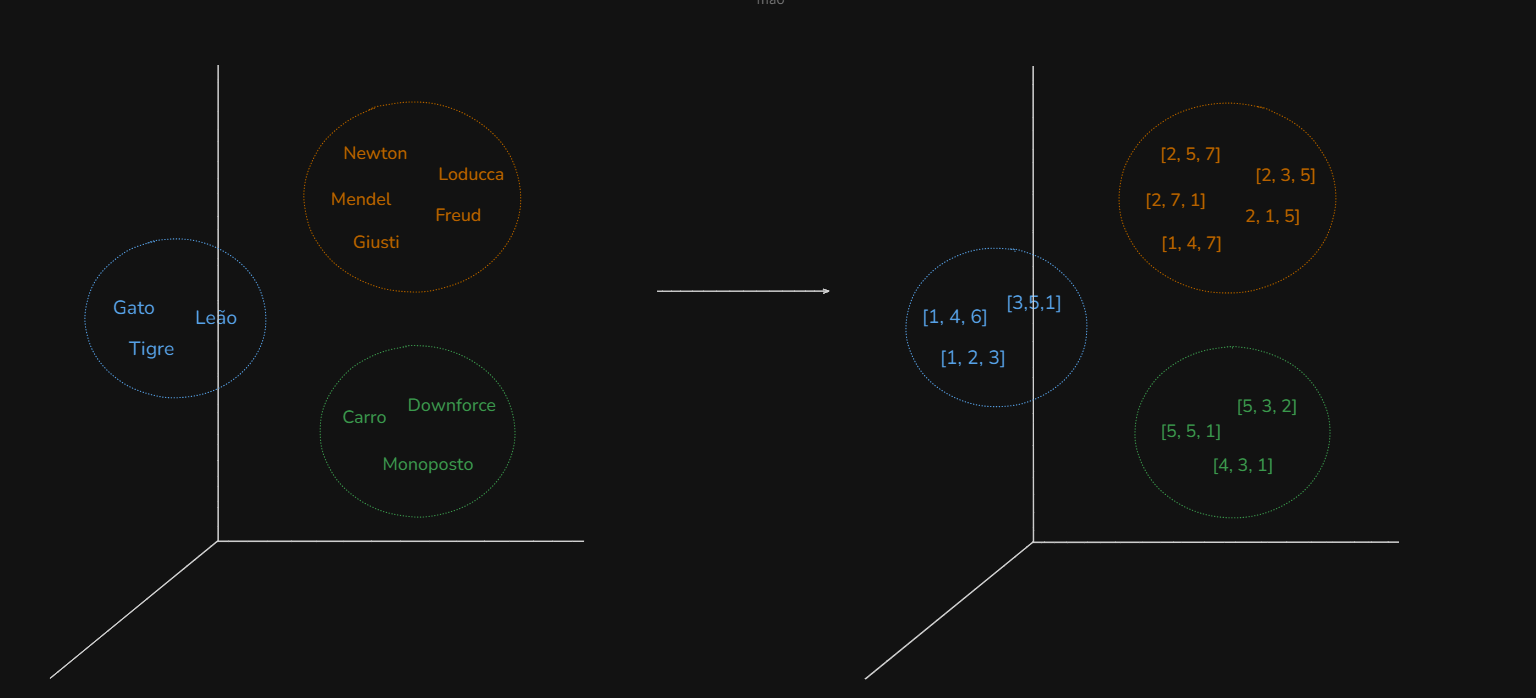

No presente notebook não irei entrar aprofundamente na arquitetura dos modelos que permitem a tradução do que está em linguagem natural para uma representação vetorial, demonstrando apenas como as sentenças passam a ser representadas segundo vetores. 

In [41]:
model = "sentence-transformers/all-mpnet-base-v2"

embedding = HuggingFaceEmbeddings(model_name=model)

text = "Wake me up when september ends"

vector_text = embedding.embed_query(text)
print(vector_text)

[-0.04569750279188156, 0.16099382936954498, -0.009237151592969894, -0.04874246567487717, -0.022382738068699837, -0.00850535649806261, -0.09219010919332504, -0.0024778516963124275, -0.05137034133076668, 0.024149594828486443, 0.09646628797054291, 0.055923763662576675, -0.005866926163434982, 0.027751538902521133, -0.05588183552026749, 0.004529646597802639, 0.007764539215713739, 0.007686386816203594, 0.032787080854177475, -0.02881602570414543, -0.026845674961805344, 0.015185760334134102, -0.03133650869131088, 0.01632586680352688, -0.0006931644165888429, -0.05581056326627731, 0.006342408712953329, 0.0049708932638168335, -0.04375707730650902, 0.031065618619322777, -0.011528780683875084, 0.01840515434741974, 0.011098857969045639, -0.025029480457305908, 1.5953879710650654e-06, -0.00433984212577343, -0.01830137148499489, -0.022114761173725128, 0.024006756022572517, -0.02615697681903839, -0.05501352250576019, -0.010472087189555168, 0.023236554116010666, 0.03550855070352554, -0.004619169514626265